# Notebook 02: Sequential Preprocessing and Tokenization

This notebook builds a **custom domain-specific tokenizer** for financial transactions and generates tokenized corpora for foundation model pretraining. Instead of treating each transaction as an independent row, we serialize a customer's transaction history into a sequence of domain-specific tokens so a language model can learn sequential patterns (spending velocity, geographic shifts, recurring merchants).

1. **Custom tokenization**: why domain-specific tokens outperform general-purpose BPE tokenizers for financial data.
2. **Corpus generation**: convert the temporal splits from notebook 01 into tokenized sequences for foundation model pretraining.

| | Original | Ray |
|---|----------|-------------|
| Tokenizer | cuDF `FinancialTokenizerPipeline` | **identical cuDF tokenizer**, reused unchanged |
| Execution | one GPU, whole split in memory | `map_batches(..., batch_format="cudf", num_gpus=1)`, streamed across workers |
| Sequence build | pandas groupby + `to_corpus_lines()` | Ray Data `groupby(uc_key).map_groups(build_sequences)` |
| Output | `*_corpus.txt` (text) | `tokenized/{train,val,test}/` (Parquet, fixed-width `input_ids`) |

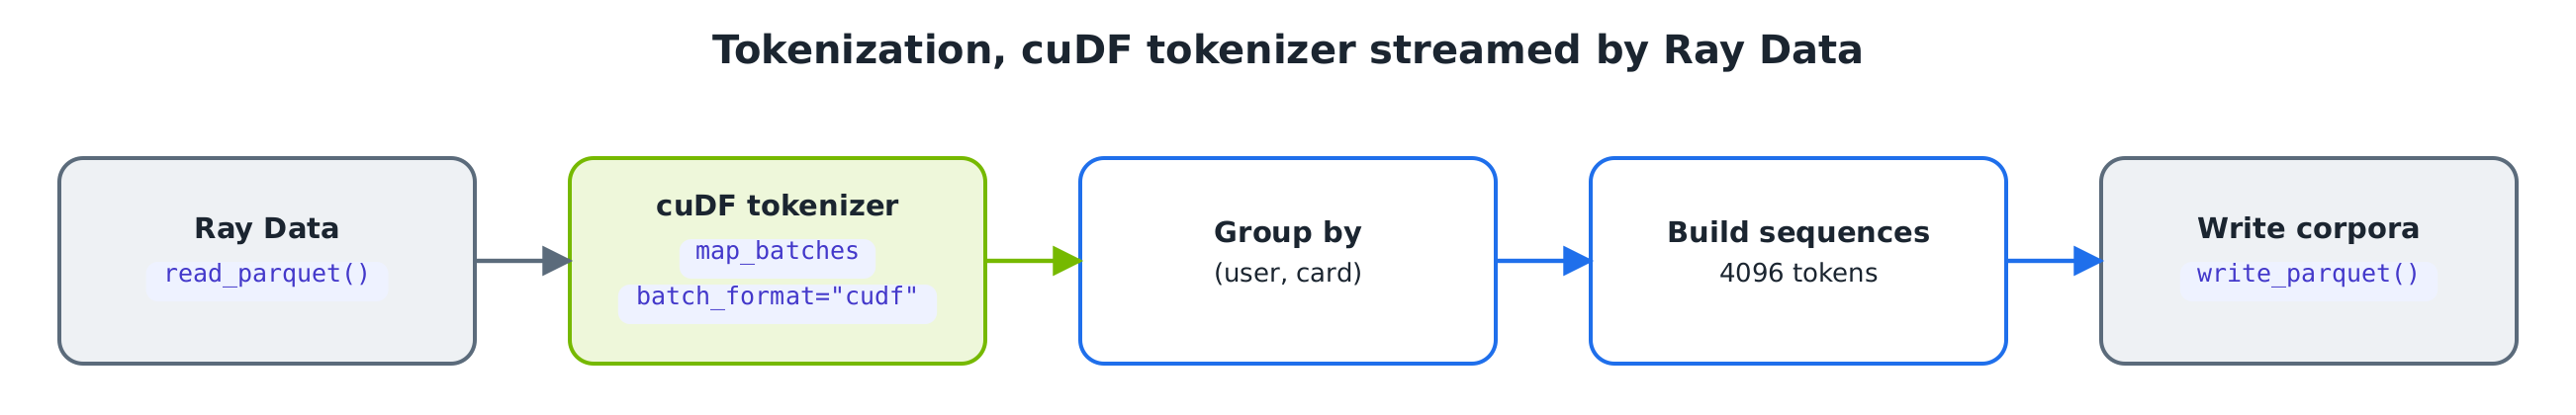

## `Step 0`: Setup

In [1]:
from pathlib import Path

import ray
from src import ray_common as C

if not ray.is_initialized():
    ray.init(address="auto", runtime_env=C.JOB_RUNTIME_ENV)
print(f"GPUs in cluster: {ray.cluster_resources().get('GPU', 0):.0f}")
print(f"Splits from NB01: {C.SPLIT_DIR}")

2026-06-10 18:46:54,322	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.128.242:6379...
2026-06-10 18:46:54,370	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at https://session-qpwcx5l3g8cwbw1p61s98gvrp4.i.anyscaleuserdata.com 
2026-06-10 18:46:54,382	INFO packaging.py:691 -- Creating a file package for local module '/home/ray/default_cld_g54aiirwj1s8t9ktgzikqur41k/transaction-foundation-model-with-ray/src'.
2026-06-10 18:46:54,389	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_567a420176897163.zip' (0.08MiB) to Ray cluster...
2026-06-10 18:46:54,390	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_567a420176897163.zip'.
2026-06-10 18:46:54,393	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_7f893cd3540c4032a4c4537887e3a071db7a6112.zip' (2.15MiB) to Ray cluster...
2026-06-10 18:46:54,401	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_7f893cd3540c4032a4c45378

GPUs in cluster: 2
Splits from NB01: /mnt/cluster_storage/tfm_ray/temporal_split


/home/ray/anaconda3/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


## `Step 1`: Tokenization Deep Dive

Standard LLM tokenizers are optimized for natural language. For tabular financial data, they often fail to capture semantic meaning efficiently:
- **Amounts**: `$123.45` might be split into `['$', '123', '.', '45']`, losing magnitude information.
- **Merchants**: `Walmart #8832` might be split into subwords, losing the entity identity.
- **Timestamps**: Dates are split into arbitrary numbers.

Our **Financial Tokenizer** uses domain-specific logic:
- **Amount Binning**: Maps amounts to log-scale bins (e.g., `AMT_3` = $100-500).
- **Merchant Hashing**: Hashes merchant names to a fixed vocabulary (e.g., `MERCH_1234`).
- **Temporal Encoding**: Encodes time as `HOUR_XX`, `DOW_X`, `MONTH_XX`.
- **Location Decomposition**: Splits location into `ZIP3_xxx` (region) + `STATE_xx`.


### `Step 1.1`: Initialize Tokenizer

We initialize our custom tokenizer and load a standard GPT-2 BPE tokenizer for comparison.

In [2]:
@ray.remote(num_gpus=1, runtime_env=C.GPU_RUNTIME_ENV)
def deep_dive():
    import cudf
    from src.tokenizer import FinancialTokenizerPipeline, FinancialTabularTokenizer
    from transformers import AutoTokenizer

    pipe = FinancialTokenizerPipeline(merchant_hash_size=2000, use_streams=False)
    fin_tok = FinancialTabularTokenizer(merchant_hash_size=2000)
    gpt2 = AutoTokenizer.from_pretrained("gpt2")

    def tok_row(overrides=None):
        row = {"Amount": ["$42.75"], "Merchant Name": ["3527213246127876953"], "MCC": [5411],
               "Year": [2025], "Month": [1], "Day": [15], "Time": ["09:32"], "Card": [0],
               "Use Chip": ["Chip Transaction"], "Zip": ["95113.0"], "Merchant State": ["CA"],
               "User": [1001]}
        if overrides:
            row.update({k: [v] for k, v in overrides.items()})
        gdf = cudf.DataFrame(row)
        proc = FinancialTokenizerPipeline.preprocess(gdf)
        pipe.fit(proc)
        tdf = pipe.transform(proc)
        per_field = {c: tdf[c].to_pandas().iloc[0] for c in tdf.columns}
        return per_field, " ".join(per_field.values())

    per_field, txn_str = tok_row()
    raw = "$42.75, 3527213246127876953, 5411, 2025-01-15, 09:32, 0, Chip Transaction, 95113, CA, 1001"
    return {
        "vocab_size": fin_tok.get_vocab_size(),
        "n_steps": len(pipe.tokenizer_order),
        "steps": list(pipe.tokenizer_order),
        "gpt2_vocab": int(gpt2.vocab_size),
        "per_field": per_field,
        "full_seq": f"<bos> {txn_str} <eos>",
        "fin_tokens": txn_str.split(),
        "gpt2_tokens": gpt2.tokenize(raw),
        "raw_text": raw,
        "big": tok_row({"Amount": "$8500.00"})[1].split()[0],
        "online": tok_row({"Use Chip": "Online Transaction", "Zip": "00000", "Merchant State": ""})[1],
        "small": tok_row({"Amount": "$0.50"})[1].split()[0],
    }

dd = ray.get(deep_dive.remote())   # one GPU task; results presented below

print(f"Financial Vocab Size: {dd['vocab_size']}")
print(f"  Pipeline steps    : {dd['n_steps']}")
print(f"  Step names        : {dd['steps']}")
print(f"GPT-2 Vocab Size    : {dd['gpt2_vocab']}")

(deep_dive pid=45608, ip=10.0.157.18) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Financial Vocab Size: 6251
  Pipeline steps    : 12
  Step names        : ['amt_val', 'merch_hash', 'mcc_int', 'mcc_str', 'hour', 'dow', 'month', 'card', 'chip_upper', 'zip3', 'state_clean', 'cust']
GPT-2 Vocab Size    : 50257


### `Step 1.2`: Sample Transaction

Tokenize a single transaction using the TabFormer schema to see the pipeline output.

In [3]:
# Per-field tokens for one sample transaction, then the assembled sequence.
print("Pipeline token output (one token per field):")
print(dd["per_field"])
print(f"\nFull token sequence:\n{dd['full_seq']}")

Pipeline token output (one token per field):
{'amt_val': 'AMT_1', 'merch_hash': 'MERCH_667', 'mcc_int': 'CAT_RETAIL', 'mcc_str': 'MCC_5411', 'hour': 'HOUR_09', 'dow': 'DOW_2', 'month': 'MONTH_01', 'card': 'CARD_0', 'chip_upper': 'CHIP_CHIP', 'zip3': 'ZIP3_951', 'state_clean': 'STATE_CA', 'cust': 'CUST_1001'}

Full token sequence:
<bos> AMT_1 MERCH_667 CAT_RETAIL MCC_5411 HOUR_09 DOW_2 MONTH_01 CARD_0 CHIP_CHIP ZIP3_951 STATE_CA CUST_1001 <eos>


### `Step 1.3`: Tokenizer Comparison

How would a general-purpose BPE tokenizer handle the same transaction? We compare our Financial Tokenizer against GPT-2 applied to a raw serialization of the tabular fields. The token count directly determines how many transactions fit into the model's fixed context window.

In [4]:
# Full sequence incl. <bos>/<eos> (matches the original's reported token count).
fin_tokens, gpt2_tokens = dd["full_seq"].split(), dd["gpt2_tokens"]

print("=" * 70)
print("TOKENIZER COMPARISON: Same Transaction, Two Approaches")
print("=" * 70)
print(f"\n--- Financial Tokenizer (domain-specific pipeline) ---")
print(f"Input : raw tabular fields → binning + hashing + encoding")
print(f"Count : {len(fin_tokens)} tokens")
print(f"Tokens: {fin_tokens}\n")
print(f"--- GPT-2 BPE Tokenizer (on raw tabular text) ---")
print(f"Input : {dd['raw_text']}")
print(f"Count : {len(gpt2_tokens)} tokens")
print(f"Tokens: {gpt2_tokens}")

TOKENIZER COMPARISON: Same Transaction, Two Approaches

--- Financial Tokenizer (domain-specific pipeline) ---
Input : raw tabular fields → binning + hashing + encoding
Count : 14 tokens
Tokens: ['<bos>', 'AMT_1', 'MERCH_667', 'CAT_RETAIL', 'MCC_5411', 'HOUR_09', 'DOW_2', 'MONTH_01', 'CARD_0', 'CHIP_CHIP', 'ZIP3_951', 'STATE_CA', 'CUST_1001', '<eos>']

--- GPT-2 BPE Tokenizer (on raw tabular text) ---
Input : $42.75, 3527213246127876953, 5411, 2025-01-15, 09:32, 0, Chip Transaction, 95113, CA, 1001
Count : 39 tokens
Tokens: ['$', '42', '.', '75', ',', 'Ġ35', '27', '213', '246', '12', '787', '69', '53', ',', 'Ġ54', '11', ',', 'Ġ2025', '-', '01', '-', '15', ',', 'Ġ09', ':', '32', ',', 'Ġ0', ',', 'ĠChip', 'ĠTransaction', ',', 'Ġ95', '113', ',', 'ĠCA', ',', 'Ġ100', '1']


### `Step 1.4`: Quantitative Summary

The token count difference has a dramatic impact on what the model can learn.

In [5]:
fin_per_txn = len(dd["fin_tokens"])      # 12 field tokens (no <bos>/<eos> in a txn)
gpt2_count = len(dd["gpt2_tokens"])
CONTEXT_WINDOW, SEP = 4096, 1
fin_txns_per_seq = CONTEXT_WINDOW // (fin_per_txn + SEP)
gpt2_txns_per_seq = CONTEXT_WINDOW // (gpt2_count + SEP)

print("=" * 70)
print("TOKENIZER COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Tokenizer':<20} {'Tokens/Txn':>12} {'Compression':>14} {'Txns in 4096':>15}")
print("-" * 70)
print(f"{'Financial':<20} {fin_per_txn:>12} {'1x (baseline)':>14} {f'~{fin_txns_per_seq}':>15}")
print(f"{'GPT-2 (BPE)':<20} {gpt2_count:>12} {f'{gpt2_count/fin_per_txn:.1f}x more':>14} {f'~{gpt2_txns_per_seq}':>15}")
print("-" * 70)
print(f"\nWith a 4096-token context window:")
print(f"  Financial tokenizer: ~{fin_txns_per_seq} transactions of temporal context")
print(f"  GPT-2 BPE tokenizer: ~{gpt2_txns_per_seq} transactions")

TOKENIZER COMPARISON SUMMARY
Tokenizer              Tokens/Txn    Compression    Txns in 4096
----------------------------------------------------------------------
Financial                      12  1x (baseline)            ~315
GPT-2 (BPE)                    39      3.2x more            ~102
----------------------------------------------------------------------

With a 4096-token context window:
  Financial tokenizer: ~315 transactions of temporal context
  GPT-2 BPE tokenizer: ~102 transactions


### `Step 1.5`: Analysis: Why This Matters

The Financial Tokenizer maps each field to **one semantically meaningful token**, while BPE tokenizers fragment raw values into subwords:

| Concept | Financial Tokenizer | GPT-2 BPE on raw text | Problem with BPE |
|---------|--------------------|-----------------------|------------------|
| Amount | `AMT_1` (1 token) | `$42`, `.`, `75` (3+ tokens) | Magnitude is lost -- `$42` and `$4,200` produce similar fragments |
| Merchant ID | `MERCH_667` (1 token) | `352`, `72`, `13`, ... (10+ tokens) | A 19-digit number explodes into meaningless digit subwords |
| Time of day | `HOUR_09` (1 token) | `09`, `:`, `32` (3 tokens) | Hour and minute are separated; temporal grouping must be learned |
| Location | `ZIP3_951` + `STATE_CA` (2 tokens) | `95`, `113`, `,`, `CA` (4+ tokens) | Full ZIP is exposed; no privacy-preserving truncation |

With a 4096-token context window, standard BPE tokenizers fit ~80-130 transactions per sequence. Our financial tokenizer fits **~315 transactions** (12 tokens each), giving the model access to months of spending history. The tokenization also provides a **privacy layer**: merchant names are hashed, amounts are binned, and ZIP codes are truncated to 3 digits.

### `Step 1.6`: Edge Cases

In [6]:
print("Large amount ($8,500):")
print(f"  {dd['big']}  (AMT_6 = $5,000+)")
print("\nOnline transaction (no physical location):")
print(f"  Tokens: {dd['online']}")
print("\nSmall amount ($0.50):")
print(f"  {dd['small']}  (AMT_0 = $0-10)")
print("\nThe tokenizer maps all amounts to 7 log-scale bins, preserving magnitude")
print("while avoiding the sparsity of exact dollar amounts.")

Large amount ($8,500):
  AMT_6  (AMT_6 = $5,000+)

Online transaction (no physical location):
  Tokens: AMT_1 MERCH_667 CAT_RETAIL MCC_5411 HOUR_09 DOW_2 MONTH_01 CARD_0 CHIP_ONLINE ZIP3_000 STATE_XX CUST_1001

Small amount ($0.50):
  AMT_0  (AMT_0 = $0-10)

The tokenizer maps all amounts to 7 log-scale bins, preserving magnitude
while avoiding the sparsity of exact dollar amounts.


## `Step 2`: Generate Tokenized Corpora (Train / Val / Test)

Convert each temporal split into sequences for causal language modeling. Transactions are grouped by (user, card), chunked into sequences of ~315 transactions, and formatted as:

```
<bos> AMT_x MERCH_x ... CUST_x <sep> AMT_x MERCH_x ... CUST_x <sep> ... <eos>
```

Each sequence is ~4096 tokens, matching the foundation model training context window.

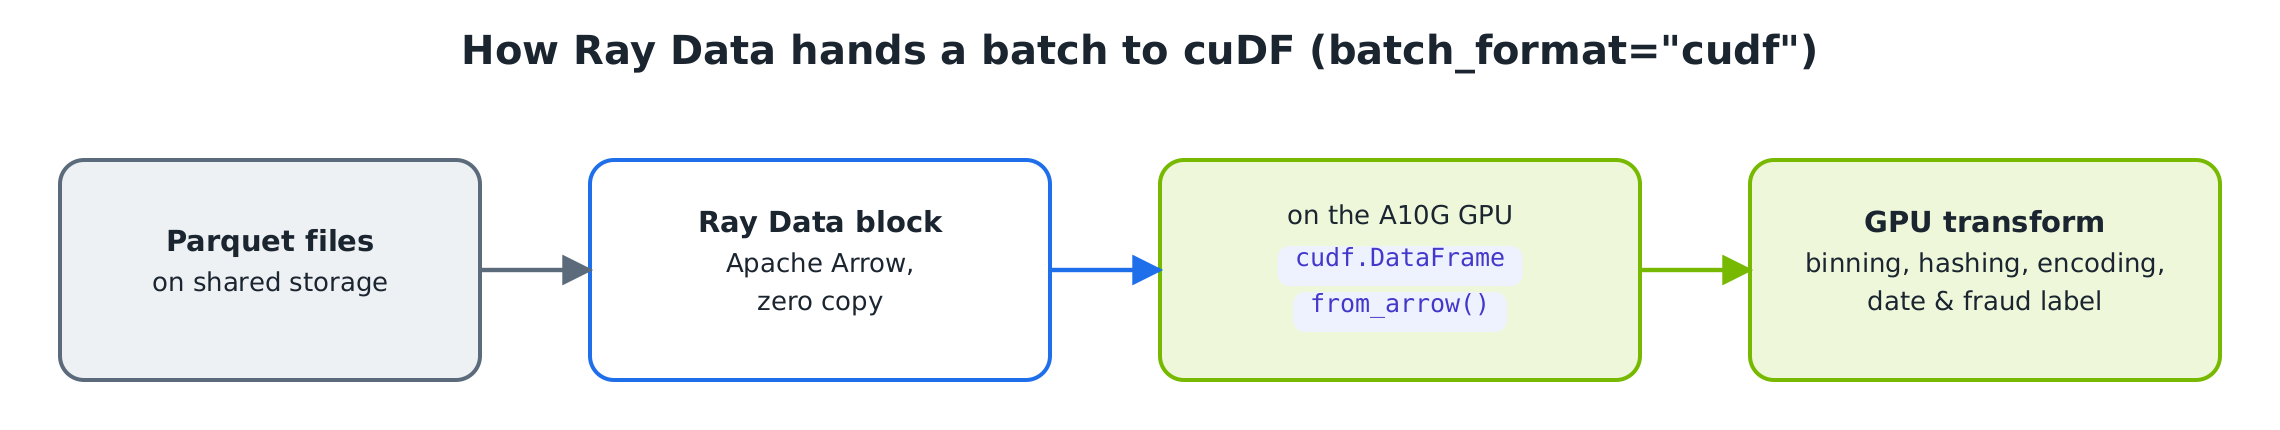

In [7]:
import json, shutil, time
from src.ray_tokenize import GPUTokenizer, build_sequences, tokenized_parquet_read_kwargs

print(f"SEQ_LENGTH={C.SEQ_LENGTH}, SEQ_CHUNK_SIZE={C.SEQ_CHUNK_SIZE} txns/seq\n")

TOKEN_META_PATH = C.TOKENIZED_DIR / "metadata.json"
SOURCE_FILES = {s: [{"path": str(p), "bytes": p.stat().st_size, "mtime_ns": p.stat().st_mtime_ns}
                    for p in sorted((C.SPLIT_DIR / s).rglob("*.parquet"))]
                for s in ["train", "val", "test"]}
EXPECTED_TOKEN_META = {
    "source_dir": str(C.SPLIT_DIR),
    "source_files": SOURCE_FILES,
    "merchant_hash_mode": C.MERCHANT_HASH_MODE,
    "merchant_hash_size": C.MERCHANT_HASH_SIZE,
    "sequence_length": C.SEQ_LENGTH,
    "sequence_chunk_size": C.SEQ_CHUNK_SIZE,
}
existing_outputs = any((C.TOKENIZED_DIR / s).exists() and any((C.TOKENIZED_DIR / s).iterdir())
                       for s in ["train", "val", "test"])
if existing_outputs:
    if not TOKEN_META_PATH.exists():
        raise RuntimeError("Existing tokenized data has no mapping metadata; clear it before rerunning NB02.")
    recorded = json.loads(TOKEN_META_PATH.read_text())
    mismatched = {k: (recorded.get(k), v) for k, v in EXPECTED_TOKEN_META.items()
                  if recorded.get(k) != v}
    if mismatched:
        raise RuntimeError(f"Existing tokenization metadata mismatch: {mismatched}")
    if not isinstance(recorded.get("sequence_counts"), dict):
        raise RuntimeError("Existing tokenization metadata lacks sequence counts.")

seq_counts = {}
for split in ["train", "val", "test"]:
    out = C.TOKENIZED_DIR / split
    # Idempotent re-runs (mirrors the original NB02): skip if already tokenized.
    if out.exists() and any(out.iterdir()):
        n = ray.data.read_parquet(str(out)).count()
        if n != recorded["sequence_counts"].get(split):
            raise RuntimeError(f"Existing {split} row count changed: {n} vs {recorded['sequence_counts'].get(split)}")
        seq_counts[split] = n
        print(f"[{split:5s}] already tokenized: {n:,} sequences at {out}")
        continue

    t0 = time.time()
    ds = ray.data.read_parquet(str(C.SPLIT_DIR / split))

    # batch_format="cudf": each block arrives on the A10G worker as a cudf.DataFrame.
    toks = ds.map_batches(
        GPUTokenizer,
        fn_constructor_kwargs={"merchant_hash_size": C.MERCHANT_HASH_SIZE,
                               "merchant_hash_mode": C.MERCHANT_HASH_MODE},
        batch_size=16384, compute=ray.data.ActorPoolStrategy(size=2), num_gpus=1,
        batch_format="cudf", runtime_env=C.GPU_RUNTIME_ENV,
    )
    seqs = toks.groupby("uc_key").map_groups(build_sequences, batch_format="numpy")

    shutil.rmtree(out, ignore_errors=True)
    seqs.write_parquet(str(out))
    n = ray.data.read_parquet(str(out)).count()
    seq_counts[split] = n
    print(f"[{split:5s}] {n:,} sequences written to {out}  ({time.time()-t0:.0f}s)")

TOKEN_META_PATH.write_text(json.dumps({**EXPECTED_TOKEN_META, "sequence_counts": seq_counts}, indent=2))

SEQ_LENGTH=4096, SEQ_CHUNK_SIZE=315 txns/seq



2026-06-10 18:48:37,055	INFO logging.py:416 -- Registered dataset logger for dataset dataset_80_0
2026-06-10 18:48:37,075	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_80_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:48:37,075	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_80_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[MapBatches(count_rows)]
2026-06-10 18:48:37,169	WARNING resource_manager.py:169 -- ⚠️  Ray's object store is configured to use only 28.1% of available memory (179.8GiB out of 640.0GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable.
2026-06-10 18:48:37,170	INFO __init__.py:56 -- Progress will be logged 

[train] already tokenized: 64,335 sequences at /mnt/cluster_storage/tfm_ray/tokenized/train
[val  ] already tokenized: 9,739 sequences at /mnt/cluster_storage/tfm_ray/tokenized/val


2026-06-10 18:48:43,584	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_84_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:48:43,584	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_84_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[MapBatches(count_rows)]
2026-06-10 18:48:43,599	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_84_0 =======
2026-06-10 18:48:43,600	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 18:48:43,600	INFO logging_progress.py:227 -- Active & requested resources: 0/128 CPU, 0.0B/72.0GiB object store
2026-06-10 18:48:43,601	INFO logging_progress.py:181 -- 
2026-06-10 18:48:43,601	INFO logging_progress.py:231 -- ListFiles: 0/1
2026-06-10 18:48:43,601	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks: 0 (0.0B); Resources: 1.0 CPU, 0.0B object store
2026-06-10 18:48:43,602	INFO logging_progress

[test ] already tokenized: 10,651 sequences at /mnt/cluster_storage/tfm_ray/tokenized/test


## `Step 3`: Verify Output

In [8]:
import numpy as np

# Per-split summary (mirrors the original's "Corpus Summary").
print("Tokenized Corpus Summary:")
print("=" * 60)
for split in ["train", "val", "test"]:
    d = ray.data.read_parquet(str(C.TOKENIZED_DIR / split))
    print(f"  {split:6s}: {d.count():>8,} sequences  (Parquet -> {C.TOKENIZED_DIR / split})")

# Inspect one training sequence.
token_document = json.loads(TOKEN_META_PATH.read_text())
train_tok = ray.data.read_parquet(
    str(C.TOKENIZED_DIR / "train"), **tokenized_parquet_read_kwargs(token_document)
)
print("\nSchema:", train_tok.schema())
row = train_tok.take(1)[0]
ids = np.asarray(row["input_ids"])
n_real = int((ids != C.PAD_TOKEN_ID).sum())
n_sep = int((ids == C.SEP_TOKEN_ID).sum())
print(f"\nSample sequence: length {len(ids)}, {n_real} non-pad tokens, {n_sep + 1} transactions")
print(f"  first 30 ids: {ids[:30].tolist()}")
print(f"  starts with <bos>={ids[0]==C.BOS_TOKEN_ID}, contains <eos>={(ids==C.EOS_TOKEN_ID).any()}")

2026-06-10 18:48:43,804	INFO logging.py:416 -- Registered dataset logger for dataset dataset_86_0
2026-06-10 18:48:43,810	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_86_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:48:43,810	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_86_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[MapBatches(count_rows)]
2026-06-10 18:48:43,825	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_86_0 =======
2026-06-10 18:48:43,826	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 18:48:43,826	INFO logging_progress.py:227 -- Active & requested resources: 0/128 CPU, 0.0B/72.0GiB object store
2026-06-10 18:48:43,827	INFO logging_progress.py:181 -- 
2026-06-10 18:48:43,827	INFO logging_progress.py:231 -- ListFiles: 0/1
2026-06-10 18:48:43,827	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blo

2026-06-10 18:48:43,902	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_86_0 execution finished in 0.09 seconds
INFO:openlineage.client.client:OpenLineageClient will use `composite` transport
INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>
2026-06-10 18:48:43,923	INFO logging.py:416 -- Registered dataset logger for dataset dataset_88_0
2026-06-10 18:48:43,928	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_88_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:48:43,929	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_88_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[MapBatches(count_rows)]


Tokenized Corpus Summary:
  train :   64,335 sequences  (Parquet -> /mnt/cluster_storage/tfm_ray/tokenized/train)


2026-06-10 18:48:43,944	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_88_0 =======
2026-06-10 18:48:43,945	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 18:48:43,945	INFO logging_progress.py:227 -- Active & requested resources: 0/128 CPU, 0.0B/72.0GiB object store
2026-06-10 18:48:43,945	INFO logging_progress.py:181 -- 
2026-06-10 18:48:43,946	INFO logging_progress.py:231 -- ListFiles: 0/1
2026-06-10 18:48:43,946	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks: 0 (0.0B); Resources: 1.0 CPU, 0.0B object store
2026-06-10 18:48:43,946	INFO logging_progress.py:231 -- MapBatches(count_rows): 0/1
2026-06-10 18:48:43,947	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 0.0B object store
2026-06-10 18:48:43,947	INFO logging_progress.py:192 -- =============================================
2026-06-10 18:48:44,001	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_88_0 execution finished

  val   :    9,739 sequences  (Parquet -> /mnt/cluster_storage/tfm_ray/tokenized/val)
  test  :   10,651 sequences  (Parquet -> /mnt/cluster_storage/tfm_ray/tokenized/test)

Schema: Column     Type
------     ----
input_ids  ArrowTensorTypeV2(shape=(4096,), dtype=int64)


(ReadFiles pid=34279, ip=10.0.187.166) /tmp/ray/session_2026-06-10_15-54-26_041190_3241/runtime_resources/pip/a4f0a9e8b1d93efeded9f38739cf8f838bce9456/virtualenv/lib/python3.12/site-packages/cudf/utils/gpu_utils.py:162: UserWarning: No NVIDIA GPU detected
(ReadFiles pid=34279, ip=10.0.187.166)   warnings.warn("No NVIDIA GPU detected")
2026-06-10 18:48:46,252	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_92_0 execution finished in 2.11 seconds
INFO:openlineage.client.client:OpenLineageClient will use `composite` transport
INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>



Sample sequence: length 4096, 664 non-pad tokens, 51 transactions
  first 30 ids: [1, 7, 1060, 2023, 2068, 2151, 2163, 2176, 2184, 2190, 2193, 3250, 3267, 3, 7, 1060, 2023, 2068, 2151, 2164, 2176, 2184, 2190, 2193, 3250, 3267, 3, 7, 1060, 2023]
  starts with <bos>=True, contains <eos>=True


## Summary

The custom Financial Tokenizer produces **3-4x fewer tokens** per transaction than
GPT-2 BPE (12 tokens vs 30-50+), enabling ~315 transactions per 4096-token
sequence. Each token captures a complete financial concept rather than arbitrary
subwords.

The **same cuDF tokenizer** now runs as a streamed **Ray Data** pipeline across
A10G workers (`batch_format="cudf"`) and writes tokenized **Parquet** sequences for
**train / val / test** to shared storage — replacing the single-GPU run and the
`*_corpus.txt` files, and feeding NB03 directly via Ray Data shards.

**Outputs:** `tokenized/{train,val,test}/` (Parquet, `input_ids` of length `SEQ_LENGTH`).

Continue to **`03_foundation_model_training_ray.ipynb`**.